In [14]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (r2_score, mean_absolute_error, 
                           mean_squared_error, explained_variance_score)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from scipy import stats
from sklearn.model_selection import train_test_split
import shap
import os

In [15]:
MODEL_PATH = "../../../models/random_forest/random_forest_model_v4_label.joblib"
DATA_PATH = "../../../data/preprocessed/selected_features_dataset.csv"
OUTPUT_DIR = "rf_model_evaluation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [16]:
print("Loading saved Random Forest model...")
try:
    rf_model = joblib.load(MODEL_PATH)
    print(f"Successfully loaded model from {MODEL_PATH}")
    print("Model parameters:")
    print(rf_model.get_params())
except Exception as e:
    print(f"Error loading model: {str(e)}")
    raise

Loading saved Random Forest model...
Successfully loaded model from ../../../models/random_forest/random_forest_model_v4_label.joblib
Model parameters:
{'bootstrap': True, 'ccp_alpha': 0.01, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 800, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [17]:
print("\nLoading and preparing data...")
df = pd.read_csv(DATA_PATH)
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']

# Split data (using same random_state as training)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nData loaded successfully:")
print(f"- Training samples: {X_train.shape[0]}")
print(f"- Test samples: {X_test.shape[0]}")
print(f"- Features: {X_train.shape[1]}")


Loading and preparing data...

Data loaded successfully:
- Training samples: 7417
- Test samples: 1855
- Features: 10


In [18]:
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

In [19]:
def calculate_metrics(y_true, y_pred, set_name):
    return {
        'Dataset': set_name,
        'R²': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE (%)': np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-8))) * 100,
        'Explained Variance': explained_variance_score(y_true, y_pred),
        'Median Absolute Error': np.median(np.abs(y_true - y_pred))
    }

metrics_df = pd.DataFrame([
    calculate_metrics(y_train, y_pred_train, 'Train'),
    calculate_metrics(y_test, y_pred_test, 'Test')
])

In [20]:
print("\nModel Performance Metrics:")
display(metrics_df.style.format({
    'R²': '{:.4f}',
    'MAE': '{:.2f}',
    'RMSE': '{:.2f}',
    'MAPE (%)': '{:.2f}',
    'Explained Variance': '{:.4f}',
    'Median Absolute Error': '{:.2f}'
}).background_gradient(cmap='Blues', subset=['R²', 'Explained Variance'])
       .background_gradient(cmap='Reds_r', subset=['MAE', 'RMSE', 'MAPE (%)', 'Median Absolute Error']))


Model Performance Metrics:


,Dataset,R²,MAE,RMSE,MAPE (%),Explained Variance,Median Absolute Error
0,Train,0.9983,49.68,95.52,5.36,0.9983,25.67
1,Test,0.9906,102.10,220.79,7.65,0.9906,44.89


In [21]:
importances = rf_model.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)
feature_names = X.columns

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Std': std
}).sort_values('Importance', ascending=False)

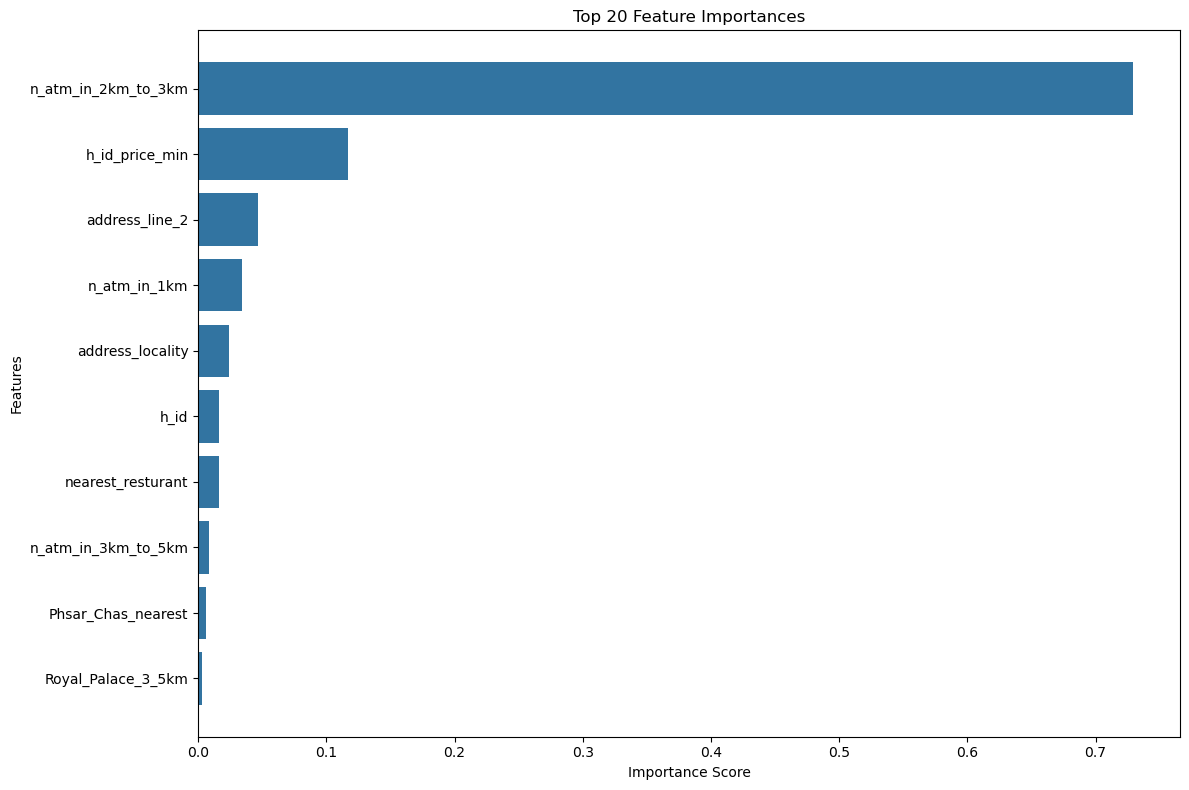

In [22]:
top_features = importance_df.head(20)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
)

# Add error bars manually
for i, (_, row) in enumerate(top_features.iterrows()):
    ax.errorbar(
        x=row['Importance'],
        y=i,
        fmt='none',
        c='black',
        capsize=5
    )

plt.title('Top 20 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [23]:
print("\nCalculating permutation importance (this may take a while)...")
perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


Calculating permutation importance (this may take a while)...


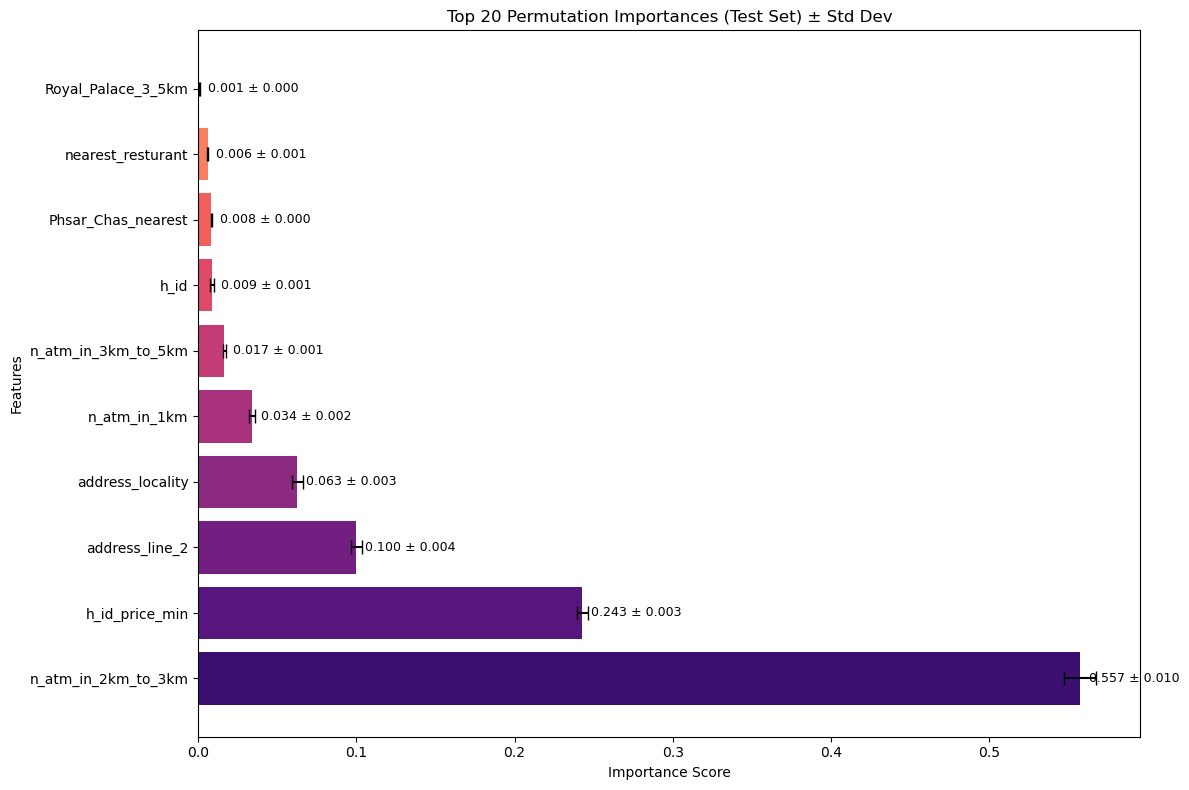

In [25]:
# Prepare permutation importance data
perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values('Importance', ascending=False)

# Select top 20 features
top_features = perm_importance_df.head(20)

# Create the plot with proper error bars
plt.figure(figsize=(12, 8))

# Get the positions for each feature
y_pos = np.arange(len(top_features))

# Create the bar plot
bars = plt.barh(
    y_pos,
    top_features['Importance'],
    xerr=top_features['Std'],
    align='center',
    color=plt.cm.magma(np.linspace(0.2, 0.8, len(top_features))),
    capsize=5
)

# Customize the plot
plt.yticks(y_pos, top_features['Feature'])
plt.title('Top 20 Permutation Importances (Test Set) ± Std Dev')
plt.xlabel('Importance Score')
plt.ylabel('Features')

# Add value labels if there's space
for i, (importance, std) in enumerate(zip(top_features['Importance'], top_features['Std'])):
    plt.text(
        importance + 0.01 * top_features['Importance'].max(),
        i,
        f'{importance:.3f} ± {std:.3f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rf_permutation_importance.png", dpi=300)
plt.show()


Calculating SHAP values...


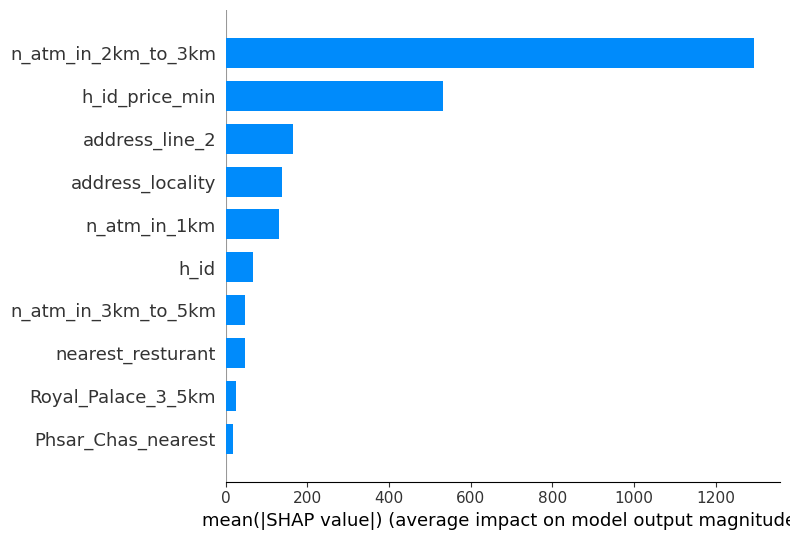

<Figure size 640x480 with 0 Axes>

In [26]:
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)
plt.tight_layout()
plt.show()

In [ ]:
# Detailed SHAP plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, max_display=20)
plt.tight_layout()
plt.show()

In [ ]:
print("\nCreating Partial Dependence Plots...")
top_features = importance_df.head(5)['Feature'].values

fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_test,
    features=top_features,
    ax=ax
)
plt.suptitle('Partial Dependence Plots for Top 5 Features')
plt.tight_layout()
plt.show()

In [ ]:
residuals = y_test - y_pred_test

# Create residual plots
plt.figure(figsize=(18, 5))

# Residual Distribution
plt.subplot(1, 3, 1)
sns.histplot(residuals, kde=True, bins=30)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')

# Residuals vs Predicted
plt.subplot(1, 3, 2)
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

# Q-Q Plot
plt.subplot(1, 3, 3)
stats.probplot(residuals, plot=plt)
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, label='Test Data')

# Add perfect prediction line
max_val = max(y_test.max(), y_pred_test.max())
min_val = min(y_test.min(), y_pred_test.min())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')

# Add regression line
coef = np.polyfit(y_test, y_pred_test, 1)
plt.plot(y_test, np.polyval(coef, y_test), 'r-', label='Regression Line')

plt.xlabel('Actual Price per m²')
plt.ylabel('Predicted Price per m²')
plt.title('Random Forest: Actual vs Predicted Prices')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
error_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_test,
    'Error': residuals,
    'Absolute_Error': np.abs(residuals),
    'Percent_Error': np.abs(residuals / y_test) * 100
})

# Bin by actual price
error_df['Price_Bin'] = pd.qcut(error_df['Actual'], q=5)
bin_stats = error_df.groupby('Price_Bin').agg({
    'Absolute_Error': ['mean', 'median', 'std'],
    'Percent_Error': ['mean', 'median']
}).round(2)

# Display and save results
print("\nError Analysis by Price Range:")
display(bin_stats)